# Resources

[1. Tutorial on time delay cacluation](https://stackoverflow.com/questions/4967453/time-delay-estimation-between-two-audio-signals)

[2. Cone of confusion definition](https://hearinghealthmatters.org/waynesworld/2023/localization-more-important-than-word-recognition/)

[3. Sound triangulation theory and practice](https://encyclopedia.pub/entry/53167)

[4. How to calculate TDOA](https://stackoverflow.com/questions/52192584/clear-simple-example-of-how-to-calculate-tdoa-time-difference-of-arrival)

In [1]:
from utils.imports import *
# 1. Define the path to your extracted ffmpeg bin folder
# (Change this to wherever you actually saved it)
ffmpeg_bin_path = r"C:\ffmpeg\ffmpeg-8.1.1-full_build-shared\bin"
# 2. Add it to the Windows PATH for this specific Python session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_path
# 3. Tell Python where to look for DLLs (Required for Python 3.8+ on Windows)
if hasattr(os, 'add_dll_directory'):
    os.add_dll_directory(ffmpeg_bin_path)
# 4. NOW you can import torchaudio safely

# Utils

### 2.2.b,c)

In [6]:
dataset_roots:dict = [r'utils\assignment_2_dataset\train',
                      r'utils\assignment_2_dataset\validation',
                      r'utils\assignment_2_dataset\test']

In [2]:
@staticmethod
def visualize_waveforms(waveforms:tuple|list, reduce:int = 500)->None:

    for index, wave in enumerate(waveforms[0]):
        PLT.plot(wave[:500], label=f"{waveforms[1][index]}")
        PLT.xlabel("Sample index")
        PLT.ylabel("Amplitude")
        PLT.legend()
        PLT.grid()
    
    PLT.show()
        
    return None

In [3]:
@staticmethod
def audio_simulator(input, source_loc:tuple, mic_locs:list|tuple):
    """
    Def:
    :params input
    :params tuple of floats source_loc: Holding the cartesian coordinates of the source; 
    :params list of tuples mic_locs: Holding the cartesian coordinates of multiple microphones. If all the microphones share the same location then the argument becomes a tuple

    Return: waveforms (visualiazation) and time_delays
    """

    def _time_delay_calculation(mic=mic_locs, source=source_loc, common_loc=False):
        for locations in mic:
            relative_time_delays.append(np.round((np.sqrt( (source[0]-locations[0])**2 + (source[1]-locations[1])**2)/c)*sr))

        # 2. Locate the furthest situated microphone by time_delay: the more samples, the furthest
        furtherst = max(relative_time_delays)
        for relative_time in relative_time_delays:
            delay = furtherst-relative_time
            waveforms.append(input[int(delay):])
    
    c:int=340*100
    sr:int = 48000
    relative_time_delays:list = []
    time_delay_of_arival:int = 0
    waveforms:list = []

    if isinstance(mic_locs, tuple):
        _time_delay_calculation(True)
    elif isinstance(mic_locs, list):
        _time_delay_calculation()
    
    
    return relative_time_delays, waveforms

Initial signal shape torch.Size([2, 396226])
Preprocessed signal shape torch.Size([396226]) with relative time delays [np.float64(326.0), np.float64(306.0)]


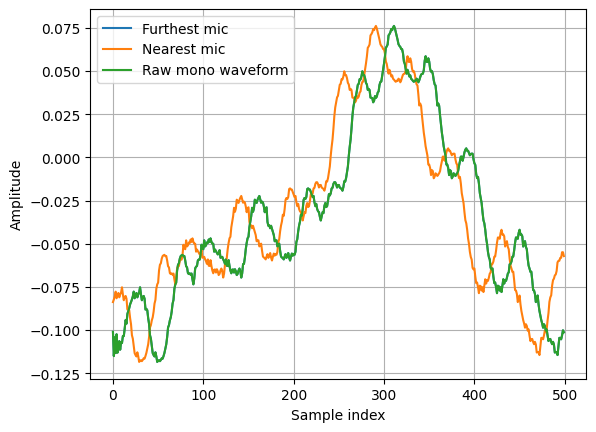

In [4]:
# 1. Loading the signal (e.g., mp3 track)
waveform, sample_rate = torchaudio.load(r'utils\assignment_2_dataset\train\curlew.mp3')
# 2. Averaging out the signal's channels - THIS IS A PREPROCESSING STEP w
mono_waveform = torch.mean(waveform, dim=0)
# 3. Calculating the time delay differences and outputting the new waveforms
relative_time_delays, waveforms = audio_simulator(input=mono_waveform, source_loc=(200, 100), mic_locs=[(-8, 0),(8, 0)])

# Informative print
print("Initial signal shape {}\nPreprocessed signal shape {} with relative time delays {}".format(waveform.shape, mono_waveform.shape, relative_time_delays))
input_for_vis = [[waveforms[0], waveforms[1],mono_waveform],["Furthest mic","Nearest mic","Raw mono waveform"]]
visualize_waveforms(input_for_vis)

Initial signal shape torch.Size([2, 396226])
Preprocessed signal shape torch.Size([396226]) with relative time delays [np.float64(374.0), np.float64(335.0), np.float64(297.0), np.float64(260.0)]


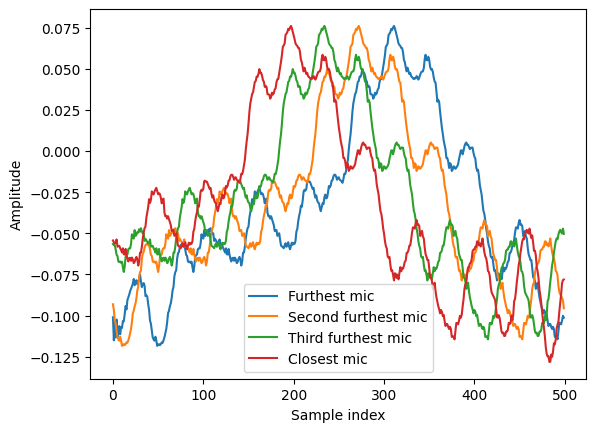

In [7]:
relative_time_delays, waveforms = audio_simulator(input=mono_waveform, source_loc=(200, 100), mic_locs=[(-45, 0),(-15, 0), (15, 0), (45, 0)])
print("Initial signal shape {}\nPreprocessed signal shape {} with relative time delays {}".format(waveform.shape, mono_waveform.shape, relative_time_delays))
input_for_vis = [[waveforms[0], waveforms[1], waveforms[2], waveforms[3]],["Furthest mic","Second furthest mic","Third furthest mic","Closest mic"]]
visualize_waveforms(input_for_vis)

### 2.2.e)

In [12]:
# 1. Calculating the sample difference between the furthest and nearest mics
sample_difference = max(relative_time_delays) - min(relative_time_delays) 
time_difference_seconds = sample_difference / sample_rate
print(f"For a sample differnece of {sample_difference} and smapling rate {sample_rate} the time difference: {time_difference_seconds:.5f} seconds")

print(relative_time_delays)

# t = m/d

For a sample differnece of 114.0 and smapling rate 48000 the time difference: 0.00237 seconds
[np.float64(374.0), np.float64(335.0), np.float64(297.0), np.float64(260.0)]


### 2.2.g)

In [75]:
class CustomAudioDecoderData(Dataset):
    """
    :param float t:
    :param list of integers mic_locs:
    :param tuple holding float values n_sources_min_max:
    ....
    """
    def __init__(self, split:str = 'train', t:float=None, mic_locs:list=None, n_sources_min_max:tuple=None, x_y_loc_min_max:tuple=None,
                 batch_size:int=64, shuffle:bool=True, data_folder='\Data', transform=False, dataset_roots=dataset_roots):

        # 1.1 Fail save, ensuring NO-CAPITAL charachters are accidentally inserted;        
        self.split = split.lower()
        # 1.2 Map split string to the correct index of dataset_roots (0=train, 1=val, 2=test)
        split_mapping = {'train': 0, 'val': 1, 'test': 2}
        if self.split not in split_mapping:
            raise ValueError("split must be 'train', 'val', or 'test'")
        # 1.3 Set a value (e.g., 0, 1 or 2) based on the subset of interest specified at class instantiation time;
        self.split_idx = split_mapping[self.split]

        self.t = t 
        self.mic_locs = mic_locs
        self.n_sources_min_max = n_sources_min_max
        self.x_y_loc_min_max = x_y_loc_min_max
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.loc=data_folder
        self.transform = transform
        self.dataset_root_paths = dataset_roots

        # 1. Collecting data paths
        all_data_paths = self._retrieve_and_assemble_data_paths()

        # 2. Declare active file paths based on step `1.3`
        self.active_paths = all_data_paths[self.split_idx]
    
    def __len__(self):
        return len(self.active_paths)

    def __getitem__(self, idx):

        # Target a single file path string using the index [1]
        file_path = self.active_paths[idx]
        
        # Safely instantiate AudioDecoder with a single string path [1]
        decoder = AudioDecoder(file_path)
        
        # Extract audio tensor stream
        waveform = decoder.get_all_samples()

        # Return the waveform sample along with any labels/targets your model needs
        return waveform

    def _retrieve_and_assemble_data_paths(self, info:bool=False):
        # 0. Declaring path containers;
        _p_dataset:list = []
        # 1. Determining the number of data sets we're interested in
        # ... commonly stays 3: train, test, val;
        for set in range(len(dataset_roots)):
            # 1.1. Retriveing the .mp3 file names
            names = os.listdir(self.dataset_root_paths[set])
            _p_dataset.append([os.path.join(self.dataset_root_paths[set],item) for item in names])

        if info:
            print(f"Container holding pahts to .mp3 files holds the following content {_p_dataset}")

        return _p_dataset


In [76]:
train_dataset = CustomAudioDecoderData(split='train', dataset_roots=dataset_roots)
val_dataset   = CustomAudioDecoderData(split='val', dataset_roots=dataset_roots)
test_dataset  = CustomAudioDecoderData(split='test', dataset_roots=dataset_roots)
